# 08 · Spatial agents, digital twins, and scenario uncertainty

**Decision question.** What does an intervention change in a transparent synthetic model, and how uncertain is that comparison?

**Time:** 30–45 minutes. **Prerequisites:** basic Python arrays and tables. Run cells from top to bottom.
The shared `rewiring.py` module must stay beside the notebooks. Initial package downloads require internet;
the core calculations use reproducible synthetic data. No health-service credentials are needed.

**Data contract:** the fictional grid is geographically anchored near Gaborone for teaching map coordinates.
Its people, facilities, climate, events, and model parameters are invented. It is **not a map of actual
Gaborone disease, vulnerability, buildings, or care access**. Satellite catalog metadata, when used, is labeled separately.

[Book](https://jltobias.github.io/JupyterLite-Rewiring-Global-Health/) · [Interactive demo gallery](https://jltobias.github.io/JupyterLite-Rewiring-Global-Health/demos/) · [Data and credits](https://github.com/jltobias/JupyterLite-Rewiring-Global-Health/blob/main/DATA_SOURCES.md)

In [1]:
import sys
if sys.platform == 'emscripten':
    import micropip
    await micropip.install(['numpy', 'pandas', 'matplotlib'])
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML, IFrame
from rewiring import (city, long_table, map_image, map_matrix, geojson,
                      leaflet, save_export, simulate_twin, teaching_review, HATS, SITE, LABEL, EXTENT)
plt.rcParams.update({'figure.dpi': 105, 'axes.spines.top': False, 'axes.spines.right': False})
cells, cube = city()
panel = long_table(cells, cube)
print(LABEL)
print('Python', sys.version.split()[0], '| cells:', len(cells), '| monthly observations:', len(panel))

SYNTHETIC teaching data · not observations or a forecast
Python 3.13.14 | cells: 64 | monthly observations: 1536


## A deliberately bounded model

The supplied Gaborone presentation describes a much richer, calibrated spatial workflow with buildings,
mobility, clinical cascades, and uncertainty. This lesson uses 640 invented agents assigned to 64 grid cells.
States are susceptible (S), latent (L), infectious (I), treatment (T), and recovered (R). The transition
probabilities are arbitrary teaching inputs, not TB natural-history estimates or Kopanyo study parameters.

Transitions use the **start-of-week state**, so an agent cannot pass through several disease states in one
week. Infection pressure combines local and citywide prevalence. Recovered agents remain recovered;
there are no births, deaths, reinfections, movement, or drug-resistance states.

![State, action, and observation loop](assets/world-model.svg)

,week,S,L,I,T,R
0,0,512,96,32,0,0
1,1,505,102,33,0,0
2,2,488,119,29,4,0
3,3,478,128,30,3,1
4,4,469,136,28,6,1


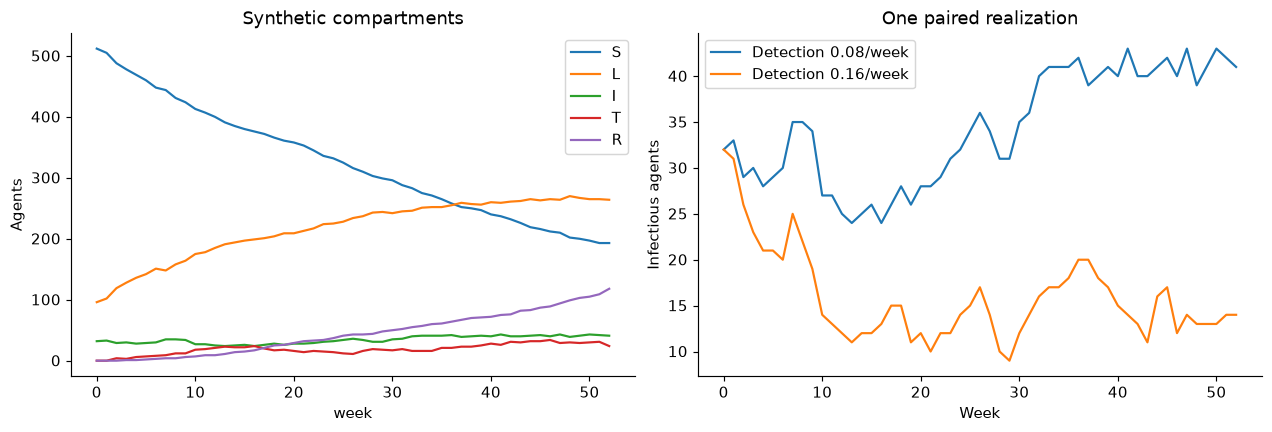

In [2]:
baseline,maps=simulate_twin(seed=3,detection=.08)
intervention,intervention_maps=simulate_twin(seed=3,detection=.16)
display(baseline.head())
fig,axes=plt.subplots(1,2,figsize=(12,4),layout='constrained')
baseline.set_index('week').plot(ax=axes[0]); axes[0].set(title='Synthetic compartments',ylabel='Agents')
axes[1].plot(baseline.week,baseline.I,label='Detection 0.08/week')
axes[1].plot(intervention.week,intervention.I,label='Detection 0.16/week')
axes[1].set(xlabel='Week',ylabel='Infectious agents',title='One paired realization'); axes[1].legend(); plt.show()

## Inspect where the model concentrates events

These cell counts describe synthetic model state, not spatial estimates of actual TB. Counts in small
populations can fluctuate strongly. The shared color scale is essential when comparing intervention rows.

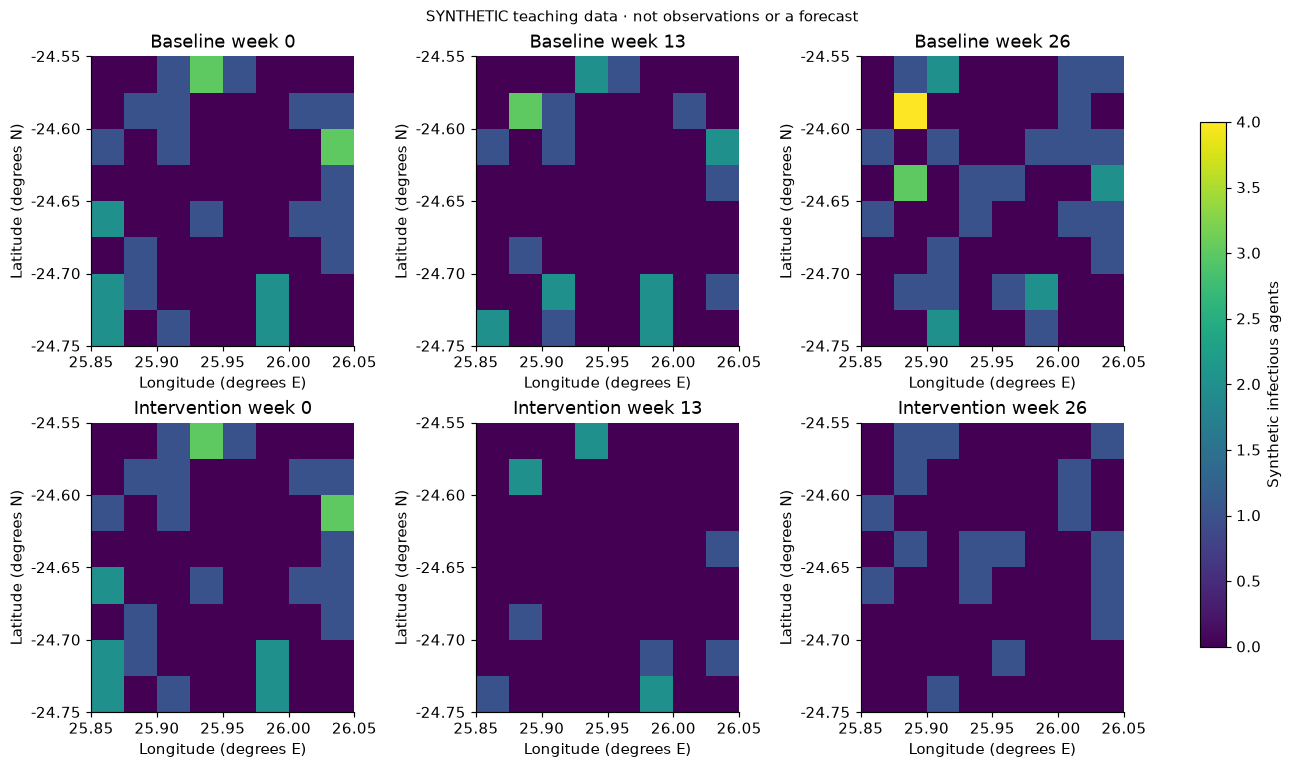

In [3]:
chosen=[0,13,26]
map_matrix(np.concatenate([maps[chosen],intervention_maps[chosen]]),
           [f'Baseline week {t}' for t in chosen]+[f'Intervention week {t}' for t in chosen],
           'Synthetic infectious agents',columns=3)
plt.show()

## Compare many paired runs

For each seed, scenarios begin with the same agents and random draws. Pairing reduces some Monte Carlo
noise but does not remove uncertainty in parameters, mechanisms, or observation processes. The interval
below describes variability across these runs, **not a confidence interval for real intervention efficacy**.

0.05     595.00
0.50     858.50
0.95    1125.05
Name: Paired synthetic agent-week difference, dtype: float64

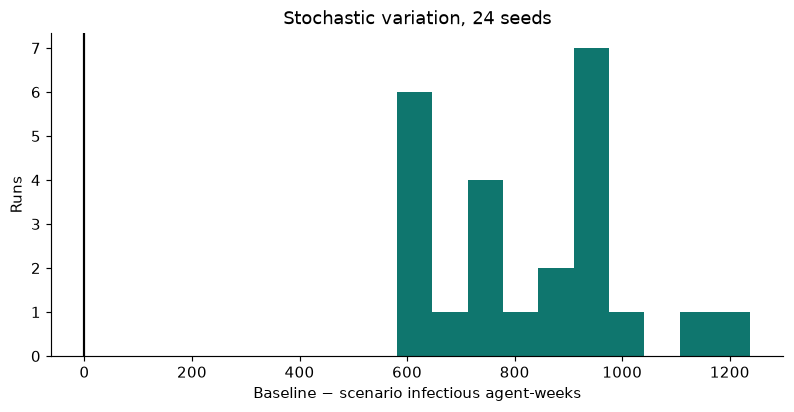

In [4]:
rows=[]
for seed in range(24):
    base,_=simulate_twin(seed,detection=.08)
    scenario,_=simulate_twin(seed,detection=.16)
    # Left endpoint convention: 52 weekly intervals, excludes the terminal point.
    b=float(base.I.iloc[:-1].sum()); s=float(scenario.I.iloc[:-1].sum())
    rows.append((seed,b,s,b-s))
trials=pd.DataFrame(rows,columns=['seed','baseline_infectious_agent_weeks','scenario_infectious_agent_weeks','difference'])
display(trials.difference.quantile([.05,.5,.95]).rename('Paired synthetic agent-week difference'))
fig,ax=plt.subplots(figsize=(9,4)); ax.hist(trials.difference,bins=10,color='#0f766e')
ax.axvline(0,color='black'); ax.set(xlabel='Baseline − scenario infectious agent-weeks',ylabel='Runs',title='Stochastic variation, 24 seeds')
plt.show()

## Parameter sensitivity and observational limits

A digital twin requires a documented relationship with observations and regular evaluation. A one-off
simulation with a map is not sufficient. Vary the invented detection probability; do not describe the
resulting curve as cost-effectiveness without a cost model and an appropriate health outcome measure.

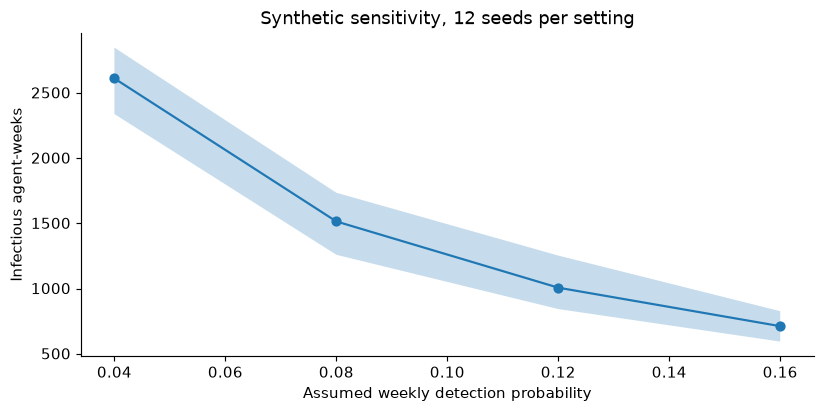

In [5]:
rows=[]
for detection in [.04,.08,.12,.16]:
    values=[simulate_twin(seed,detection=detection)[0].I.iloc[:-1].sum() for seed in range(12)]
    rows.append([detection,np.mean(values),*np.quantile(values,[.1,.9])])
sensitivity=pd.DataFrame(rows,columns=['detection','mean','p10','p90'])
fig,ax=plt.subplots(figsize=(9,4)); ax.plot(sensitivity.detection,sensitivity['mean'],marker='o')
ax.fill_between(sensitivity.detection,sensitivity.p10,sensitivity.p90,alpha=.25)
ax.set(xlabel='Assumed weekly detection probability',ylabel='Infectious agent-weeks',title='Synthetic sensitivity, 12 seeds per setting'); plt.show()

In [6]:
model_card={'purpose':'Teach spatial simulation and scenario comparison',
 'population':'640 invented agents; no Kopanyo participant data',
 'time_step':'one week; synchronous transitions',
 'calibration':'none', 'validation':'state conservation and reproducibility only',
 'not_represented':['HIV','subclinical TB','MDR','households','mobility','deaths','care costs'],
 'evidence_needed':['governed data','clinical and epidemiologic review','calibration','external validation','community review']}
display(pd.Series(model_card)); print(save_export('model-card.json',model_card))

purpose             Teach spatial simulation and scenario comparison
population          640 invented agents; no Kopanyo participant data
time_step                          one week; synchronous transitions
calibration                                                     none
validation               state conservation and reproducibility only
not_represented    [HIV, subclinical TB, MDR, households, mobilit...
evidence_needed    [governed data, clinical and epidemiologic rev...
dtype: object

exports\model-card.json


## Investigate, interpret, and discuss

1. Change the weight on local infection pressure in `simulate_twin`; compare spatial patterns.
2. Add an observation model that detects only some infectious agents. Distinguish notifications from prevalence.
3. Explain why a reduction in infectious agent-weeks cannot automatically be labeled deaths or DALYs averted.
4. Specify calibration targets, external validation data, and governance before a real decision-support pilot.

**Before sharing:** state the decision, data status, units, denominator, scale, uncertainty, and who can contest the result.
Record what would change your conclusion. Export only information that the intended audience needs.

## Sources and attribution

- Tobias, J. L., Tolentino, H., Wuhib, T., Moonan, P., & Oeltmann, J. (2026), supplied Gaborone/Kopanyo presentation, pp. 4, 14–17, 21.
- [Starsim](https://starsim.org/), named in the presentation; this lesson implements an independent small NumPy model.
- No source study data or confidential system artifacts are redistributed.

Original lesson code: MIT. Original narrative, synthetic data, and generated figures: CC BY 4.0.
Third-party data, videos, services, and software retain their own terms.
[Full references](https://github.com/jltobias/JupyterLite-Rewiring-Global-Health/blob/main/REFERENCES.md) · [Third-party notices](https://github.com/jltobias/JupyterLite-Rewiring-Global-Health/blob/main/THIRD_PARTY_NOTICES.md).